In [1]:
import pandas as pd

df = pd.read_csv("hockey_dataset.csv")

print(df.head())
print(df.info())

                 Team  Year  Wins  Losses  Goals_For  Goals_Against
0       Boston Bruins  1990    44      24        299            264
1      Buffalo Sabres  1990    31      30        292            278
2      Calgary Flames  1990    46      26        344            263
3  Chicago Blackhawks  1990    49      23        284            211
4   Detroit Red Wings  1990    34      38        273            298
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Team           25 non-null     object
 1   Year           25 non-null     int64 
 2   Wins           25 non-null     int64 
 3   Losses         25 non-null     int64 
 4   Goals_For      25 non-null     int64 
 5   Goals_Against  25 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 1.3+ KB
None


In [2]:
# column names
print(df.columns)

# data types
print(df.dtypes)

# missing values check
print(df.isnull().sum())

Index(['Team', 'Year', 'Wins', 'Losses', 'Goals_For', 'Goals_Against'], dtype='object')
Team             object
Year              int64
Wins              int64
Losses            int64
Goals_For         int64
Goals_Against     int64
dtype: object
Team             0
Year             0
Wins             0
Losses           0
Goals_For        0
Goals_Against    0
dtype: int64


In [3]:
print(df.describe())

              Year       Wins     Losses   Goals_For  Goals_Against
count    25.000000  25.000000  25.000000   25.000000       25.00000
mean   1990.160000  34.480000  34.520000  276.680000      276.80000
std       0.374166   8.155366   7.567034   33.071539       29.72513
min    1990.000000  16.000000  22.000000  223.000000      211.00000
25%    1990.000000  31.000000  30.000000  256.000000      263.00000
50%    1990.000000  34.000000  36.000000  272.000000      272.00000
75%    1990.000000  39.000000  38.000000  296.000000      298.00000
max    1991.000000  49.000000  50.000000  344.000000      354.00000


In [4]:
# top 5 teams by wins
top_wins = df.sort_values(by="Wins", ascending=False).head(5)
print(top_wins)

                  Team  Year  Wins  Losses  Goals_For  Goals_Against
3   Chicago Blackhawks  1990    49      23        284            211
16     St. Louis Blues  1990    47      22        310            250
2       Calgary Flames  1990    46      26        344            263
7    Los Angeles Kings  1990    46      24        340            254
0        Boston Bruins  1990    44      24        299            264


In [5]:
# check duplicates
print(df.duplicated().sum())

# check weird values
print(df[df["Wins"] < 0])

0
Empty DataFrame
Columns: [Team, Year, Wins, Losses, Goals_For, Goals_Against]
Index: []


In [6]:
import pandas as pd

df = pd.read_csv("hockey_dataset.csv")

# convert numeric columns
df["Wins"] = df["Wins"].astype(int)

top_teams = df.sort_values(by="Wins", ascending=False).head(10)

print(top_teams[["Team", "Year", "Wins"]])

                   Team  Year  Wins
3    Chicago Blackhawks  1990    49
16      St. Louis Blues  1990    47
2        Calgary Flames  1990    46
7     Los Angeles Kings  1990    46
0         Boston Bruins  1990    44
14  Pittsburgh Penguins  1990    41
9    Montreal Canadiens  1990    39
5       Edmonton Oilers  1990    37
19  Washington Capitals  1990    37
21        Boston Bruins  1991    36


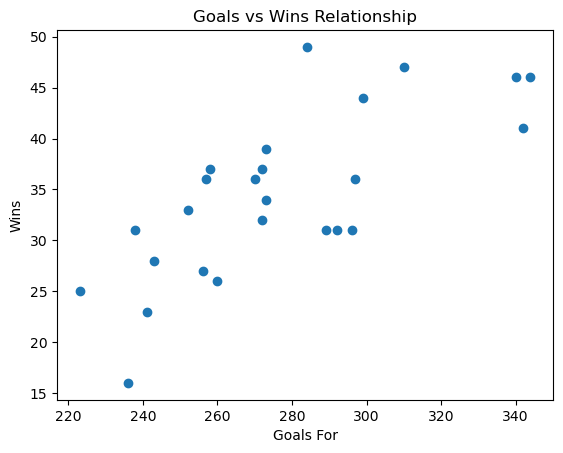

In [7]:
import matplotlib.pyplot as plt

df["Goals_For"] = df["Goals_For"].astype(int)
df["Wins"] = df["Wins"].astype(int)

plt.scatter(df["Goals_For"], df["Wins"])
plt.xlabel("Goals For")
plt.ylabel("Wins")
plt.title("Goals vs Wins Relationship")
plt.show()

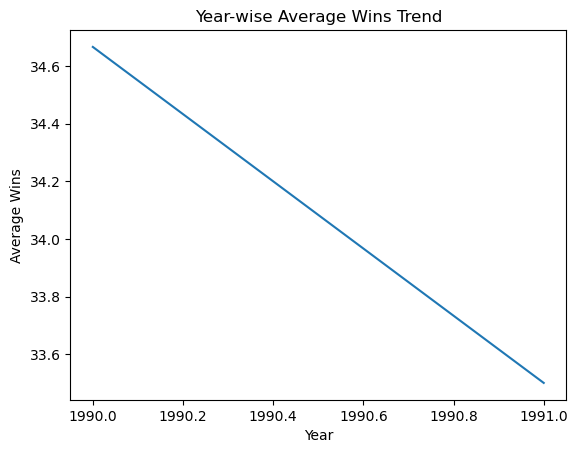

In [8]:
yearly = df.groupby("Year")["Wins"].mean().reset_index()

plt.plot(yearly["Year"], yearly["Wins"])
plt.xlabel("Year")
plt.ylabel("Average Wins")
plt.title("Year-wise Average Wins Trend")
plt.show()

In [9]:
import pandas as pd

df = pd.read_csv("hockey_dataset.csv")

df["Wins"] = df["Wins"].astype(int)

# very high wins (possible outliers)
outliers = df[df["Wins"] > df["Wins"].quantile(0.95)]

print(outliers[["Team", "Year", "Wins"]])

                  Team  Year  Wins
3   Chicago Blackhawks  1990    49
16     St. Louis Blues  1990    47


In [10]:
low_perf = df[df["Wins"] < df["Wins"].quantile(0.10)]

print(low_perf[["Team", "Year", "Wins"]])

                   Team  Year  Wins
11   New York Islanders  1990    25
15     Quebec Nordiques  1990    16
17  Toronto Maple Leafs  1990    23


In [11]:
df["Goals_For"] = df["Goals_For"].astype(int)

correlation = df["Goals_For"].corr(df["Wins"])

print("Correlation between Goals and Wins:", correlation)

Correlation between Goals and Wins: 0.739657239978379
